In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

In [6]:

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras import layers, models

In [17]:
import tensorflow as tf
from tensorflow.keras import layers

class VisionTransformer(tf.keras.Model):
    def __init__(self, num_classes, image_size=224, patch_size=16, num_layers=8, d_model=64, num_heads=4, mlp_dim=128):
        super(VisionTransformer, self).__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = (patch_size ** 2) * 3
        
        # Patch embedding layer
        self.patch_embed = layers.Conv2D(
            filters=d_model, kernel_size=patch_size, strides=patch_size, padding='valid'
        )
        
        # Positional embedding
        self.position_embedding = tf.Variable(
            tf.random.normal([1, self.num_patches, d_model]), trainable=True
        )
        
        # Transformer encoder layers
        self.encoder_layers = []
        for _ in range(num_layers):
            self.encoder_layers.append([
                layers.LayerNormalization(),
                layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model),
                layers.LayerNormalization(),
                layers.Dense(mlp_dim, activation='relu'),
                layers.Dense(d_model)
            ])
        
        # Classifier
        self.flatten = layers.Flatten()
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, x):
        # Create patches and embed them
        x = self.patch_embed(x)
        batch_size = tf.shape(x)[0]
        x = tf.reshape(x, [batch_size, self.num_patches, -1])  # Flatten patches
        x += self.position_embedding

        # Pass through transformer encoder
        for norm1, mha, norm2, dense1, dense2 in self.encoder_layers:
            # Attention block
            attn_output = mha(norm1(x), norm1(x))
            x = x + attn_output  # Residual connection
            
            # MLP block
            mlp_output = dense2(dense1(norm2(x)))
            x = x + mlp_output  # Residual connection
        
        # Classification
        x = self.flatten(x)
        return self.classifier(x)


In [18]:
data_dir = r"A:/AI_PROJECT/Fish Classification/Fish_Dataset"  # Update this with your dataset path
image_size = 224
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Training data generator
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data generator
validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Model Initialization
num_classes = train_generator.num_classes  # Dynamically detect number of classes
model = VisionTransformer(num_classes=num_classes)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Training the Model
history = model.fit(
    train_generator,
    epochs=10,  # Adjust epochs as needed
    validation_data=validation_generator
)

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 740s 3s/step - accuracy: 0.2752 - loss: 9.3571 - val_accuracy: 0.4844 - val_loss: 2.6454
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.6987 - loss: 0.9715 - val_accuracy: 0.6011 - val_loss: 1.2881
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.8121 - loss: 0.5740 - val_accuracy: 0.7244 - val_loss: 1.0650
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.9066 - loss: 0.2642 - val_accuracy: 0.7361 - val_loss: 0.9995
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.9361 - loss: 0.1988 - val_accuracy: 0.7933 - val_loss: 0.8130
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - accuracy: 0.9660 - loss: 0.0889 - val_accuracy: 0.7511 - val_loss: 1.0972
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 495s 2s/step - accuracy: 0.9536 - loss: 0.1466 - val_accuracy: 0.7856 - val_loss: 1.0894
Epoch 8/10
22

Final Training Accuracy: 0.9554166793823242
Final Validation Accuracy: 0.8216666579246521


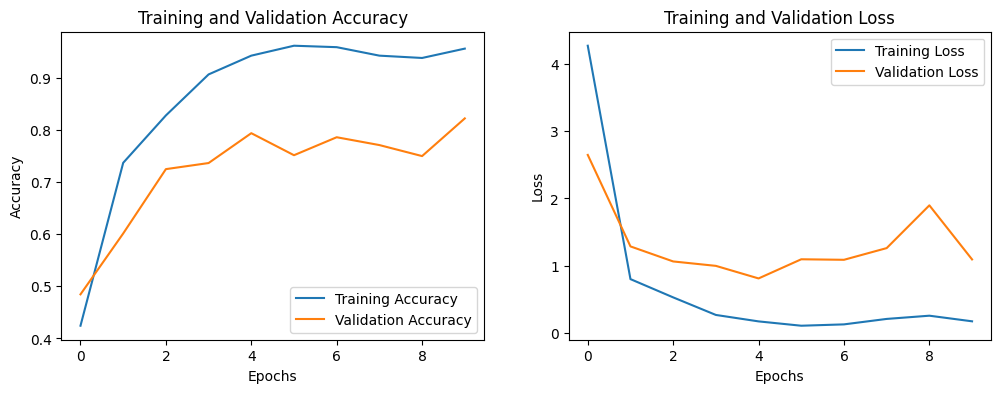

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class: [3]
Predictions: [[5.0643581e-04 6.9535039e-10 1.4237974e-04 8.4429568e-01 1.3328923e-08
  2.0440508e-07 1.5426794e-01 1.6462644e-05 7.7080750e-04]]


In [23]:
# Evaluate Accuracy
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {train_accuracy}")
print(f"Final Validation Accuracy: {val_accuracy}")

# Plot Accuracy and Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

# Prediction Pipeline
def predict_image(model, image_path):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    image = load_img(image_path, target_size=(image_size, image_size))
    image = img_to_array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    predictions = model.predict(image)
    predicted_class = np.argmax(predictions, axis=1)
    return predicted_class, predictions

# Example Prediction
image_path = r"A:/AI_PROJECT/Fish Classification/Test_images/00001.png"  # Update with the path to your test image
predicted_class, predictions = predict_image(model, image_path)
print(f"Predicted Class: {predicted_class}")
print(f"Predictions: {predictions}")
